In [1]:
# ==============================================================
# CAPITOLO 4 — VOLATILITÀ E MODELLO GARCH(1,1)
# Tesi triennale — S&P 500 Daily Total Return (1990–2024)
#
# Struttura:
#   CELLA 1 — Setup e caricamento dati
#   CELLA 2 — Evidenza del volatility clustering
#   CELLA 3 — Stima GARCH(1,1) con residui Normali
#   CELLA 4 — Stima GARCH(1,1) con residui t-Student
#   CELLA 5 — Confronto AIC/BIC tra i due modelli
#   CELLA 6 — Analisi residui standardizzati
#   CELLA 7 — VaR dinamico: Normale vs t-Student
#   CELLA 8 — Grafici: volatilità condizionale e VaR
#   CELLA 9 — Tabella riassuntiva finale
# ==============================================================
 
 
# ==============================================================
# CELLA 1 — Setup e caricamento dati
# ==============================================================
 
%matplotlib inline
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, t as student_t, jarque_bera, kurtosis
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")
 
sp = pd.read_csv(
  "../data/dailytotalreturn_S&P.csv"
)
sp["DlyCalDt"] = pd.to_datetime(sp["DlyCalDt"])
sp = sp.sort_values("DlyCalDt").reset_index(drop=True)
r = sp["DlyTotRet"].dropna().values
 
print(f"Osservazioni: {len(r)}")
print(f"Periodo: {sp['DlyCalDt'].min().date()} → {sp['DlyCalDt'].max().date()}")
print("Dati caricati ✓")

Osservazioni: 8817
Periodo: 1990-01-02 → 2024-12-31
Dati caricati ✓


In [2]:
# ==============================================================
# CELLA 2 — Evidenza del volatility clustering
#
# PERCHÉ LO FACCIAMO:
# Prima di stimare il GARCH dobbiamo mostrare che il volatility
# clustering esiste davvero nei dati. Lo facciamo in tre modi:
#
# 1) Grafico dei rendimenti al quadrato (r²): se ci fosse
#    indipendenza, i picchi sarebbero distribuiti casualmente.
#    Invece si raggruppano — questa è la firma visiva del clustering.
#
# 2) Autocorrelazione di r²: se i rendimenti fossero i.i.d.,
#    l'autocorrelazione di r² sarebbe zero a tutti i lag.
#    Valori significativi a lag 1,2,...,20 confermano che la
#    varianza di oggi dipende da quella di ieri.
#
# 3) Test di Engle (ARCH-LM test): test formale per la presenza
#    di effetti ARCH nei residui. Rifiuto → il GARCH è giustificato.
# ==============================================================
 
# --- Autocorrelazione di r² ---
r2 = r ** 2
max_lag = 20
acf_r2 = [np.corrcoef(r2[:-lag], r2[lag:])[0, 1] for lag in range(1, max_lag + 1)]
 
# --- Test ARCH-LM (Engle 1982) ---
# Regressione di r²_t su r²_{t-1}, ..., r²_{t-q}
q = 10
Y = r2[q:]
X = np.column_stack([r2[q-i:-i] for i in range(1, q+1)])
X = np.column_stack([np.ones(len(Y)), X])
beta = np.linalg.lstsq(X, Y, rcond=None)[0]
resid = Y - X @ beta
SS_res = np.sum(resid**2)
SS_tot = np.sum((Y - Y.mean())**2)
R2 = 1 - SS_res / SS_tot
LM_stat = len(Y) * R2
from scipy.stats import chi2
LM_pvalue = 1 - chi2.cdf(LM_stat, df=q)
 
print("=" * 55)
print("EVIDENZA DI VOLATILITY CLUSTERING")
print("=" * 55)
print(f"\nAutocorrelazione di r² (lag 1–5):")
for i in range(5):
    print(f"  lag {i+1}: {acf_r2[i]:.4f}")
print(f"\nTest ARCH-LM (Engle 1982), q={q} lag:")
print(f"  LM statistic: {LM_stat:.2f}")
print(f"  p-value:      {LM_pvalue:.6f}")
print(f"  → {'Rifiuto H0: effetti ARCH presenti ***' if LM_pvalue < 0.01 else 'Non rifiuto H0'}")
print("\nInterpretazione: autocorrelazioni positive e significative")
print("di r² confermano che la varianza non è costante nel tempo.")
print("Il GARCH(1,1) è giustificato.")

EVIDENZA DI VOLATILITY CLUSTERING

Autocorrelazione di r² (lag 1–5):
  lag 1: 0.3157
  lag 2: 0.4205
  lag 3: 0.2443
  lag 4: 0.2951
  lag 5: 0.3135

Test ARCH-LM (Engle 1982), q=10 lag:
  LM statistic: 2396.18
  p-value:      0.000000
  → Rifiuto H0: effetti ARCH presenti ***

Interpretazione: autocorrelazioni positive e significative
di r² confermano che la varianza non è costante nel tempo.
Il GARCH(1,1) è giustificato.


In [3]:

# ==============================================================
# CELLA 3 — Stima GARCH(1,1) con residui Normali
#
# MODELLO:
#   r_t = μ + ε_t,    ε_t = σ_t · z_t,    z_t ~ N(0,1)
#   σ²_t = ω + α·ε²_{t-1} + β·σ²_{t-1}
#
# PARAMETRI:
#   ω (omega) > 0 : varianza di lungo periodo
#   α (alpha) ≥ 0 : reazione agli shock recenti (ε²_{t-1})
#   β (beta)  ≥ 0 : persistenza della varianza (σ²_{t-1})
#   α + β < 1     : condizione di stazionarietà
#   α + β ≈ 1     : alta persistenza della volatilità (tipico)
#
# Stimiamo via MLE: massimizziamo la log-likelihood gaussiana
# rispetto a (μ, ω, α, β).
# ==============================================================
 
def garch_variance(params, r):
    """Calcola la sequenza di varianze condizionali σ²_t."""
    mu, omega, alpha, beta = params
    eps = r - mu
    T = len(r)
    sigma2 = np.empty(T)
    sigma2[0] = np.var(r)           # inizializzazione con varianza incondizionale
    for t in range(1, T):
        sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
    return sigma2, eps
 
def neg_loglik_norm(params, r):
    """Negative log-likelihood GARCH(1,1) con innovazioni normali."""
    mu, omega, alpha, beta = params
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
        return 1e10
    sigma2, eps = garch_variance(params, r)
    if np.any(sigma2 <= 0):
        return 1e10
    ll = -0.5 * np.sum(np.log(2 * np.pi * sigma2) + eps**2 / sigma2)
    return -ll
 
# Ottimizzazione
x0_norm = [r.mean(), 1e-6, 0.08, 0.88]
bounds = [(None, None), (1e-8, None), (0, 1), (0, 1)]
res_norm = minimize(neg_loglik_norm, x0_norm, args=(r,),
                    method="L-BFGS-B", bounds=bounds,
                    options={"maxiter": 2000, "ftol": 1e-12})
 
mu_n, omega_n, alpha_n, beta_n = res_norm.x
ll_norm_g = -res_norm.fun
 
print("=" * 55)
print("GARCH(1,1) — RESIDUI NORMALI")
print("=" * 55)
print(f"  μ (media):          {mu_n:.6f}")
print(f"  ω (omega):          {omega_n:.8f}")
print(f"  α (alpha):          {alpha_n:.6f}")
print(f"  β (beta):           {beta_n:.6f}")
print(f"  α + β:              {alpha_n + beta_n:.6f}  (< 1 ✓)" if alpha_n + beta_n < 1 else f"  α + β:              {alpha_n + beta_n:.6f}  ⚠ ≥ 1")
print(f"  Log-likelihood:     {ll_norm_g:.2f}")
print(f"\nInterpretazione:")
print(f"  α = {alpha_n:.4f} → reazione agli shock recenti")
print(f"  β = {beta_n:.4f} → alta persistenza della volatilità")
hl = -np.log(2) / np.log(alpha_n + beta_n)
print(f"  Half-life volatilità: {hl:.1f} giorni")

GARCH(1,1) — RESIDUI NORMALI
  μ (media):          0.000466
  ω (omega):          0.00000286
  α (alpha):          0.080000
  β (beta):           0.880000
  α + β:              0.960000  (< 1 ✓)
  Log-likelihood:     28871.63

Interpretazione:
  α = 0.0800 → reazione agli shock recenti
  β = 0.8800 → alta persistenza della volatilità
  Half-life volatilità: 17.0 giorni


In [4]:
# ==============================================================
# CELLA 4 — Stima GARCH(1,1) con residui t-Student
#
# MODELLO:
#   z_t ~ t(ν)  invece di N(0,1)
#
# Aggiunge il parametro ν (gradi di libertà) che cattura
# i fat tails nei residui standardizzati.
# Se ν stimato è basso (< 6), significa che i fat tails
# persistono anche dopo aver modellato il clustering —
# sono strutturali, non solo un artefatto della varianza
# time-varying.
# ==============================================================
 
def neg_loglik_t(params, r):
    """Negative log-likelihood GARCH(1,1) con innovazioni t-Student."""
    mu, omega, alpha, beta, nu = params
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1 or nu <= 2:
        return 1e10
    sigma2, eps = garch_variance([mu, omega, alpha, beta], r)
    if np.any(sigma2 <= 0):
        return 1e10
    # Log-likelihood t-Student standardizzata
    z = eps / np.sqrt(sigma2)
    ll = np.sum(
        student_t.logpdf(z, df=nu) - 0.5 * np.log(sigma2)
    )
    return -ll
 
x0_t = [r.mean(), 1e-6, 0.08, 0.88, 5.0]
bounds_t = [(None, None), (1e-8, None), (0, 1), (0, 1), (2.01, 50)]
res_t = minimize(neg_loglik_t, x0_t, args=(r,),
                 method="L-BFGS-B", bounds=bounds_t,
                 options={"maxiter": 2000, "ftol": 1e-12})
 
mu_t, omega_t, alpha_t, beta_t, nu_t = res_t.x
ll_t_g = -res_t.fun
 
print("=" * 55)
print("GARCH(1,1) — RESIDUI t-STUDENT")
print("=" * 55)
print(f"  μ (media):          {mu_t:.6f}")
print(f"  ω (omega):          {omega_t:.8f}")
print(f"  α (alpha):          {alpha_t:.6f}")
print(f"  β (beta):           {beta_t:.6f}")
print(f"  α + β:              {alpha_t + beta_t:.6f}")
print(f"  ν (gradi libertà):  {nu_t:.4f}")
print(f"  Log-likelihood:     {ll_t_g:.2f}")
print(f"\nInterpretazione:")
if nu_t < 4:
    print(f"  ν = {nu_t:.2f} → kurtosis teorica infinita nei residui")
    print(f"  I fat tails persistono anche dopo il GARCH:")
    print(f"  sono strutturali, non solo un artefatto del clustering.")
elif nu_t < 6:
    print(f"  ν = {nu_t:.2f} → code ancora molto pesanti nei residui")
else:
    print(f"  ν = {nu_t:.2f} → code moderate nei residui")

GARCH(1,1) — RESIDUI t-STUDENT
  μ (media):          0.000854
  ω (omega):          0.00000064
  α (alpha):          0.080000
  β (beta):           0.880000
  α + β:              0.960000
  ν (gradi libertà):  5.0000
  Log-likelihood:     29104.76

Interpretazione:
  ν = 5.00 → code ancora molto pesanti nei residui


In [5]:
# ==============================================================
# CELLA 5 — Confronto AIC/BIC
#
# GARCH Normale: 4 parametri (μ, ω, α, β)
# GARCH t:       5 parametri (μ, ω, α, β, ν)
# ==============================================================
 
n = len(r)
 
def aic_bic(ll, k, n):
    return -2*ll + 2*k, -2*ll + k*np.log(n)
 
aic_gn, bic_gn = aic_bic(ll_norm_g, 4, n)
aic_gt, bic_gt = aic_bic(ll_t_g,    5, n)
 
best_aic = min(aic_gn, aic_gt)
 
print("=" * 60)
print("CONFRONTO AIC/BIC — GARCH Normale vs GARCH t-Student")
print("=" * 60)
print(f"{'Modello':<20} {'LogL':>10} {'AIC':>10} {'BIC':>10} {'ΔAIC':>8}")
print("-" * 60)
print(f"{'GARCH-Normal':<20} {ll_norm_g:>10.1f} {aic_gn:>10.1f} {bic_gn:>10.1f} {aic_gn-best_aic:>8.1f}")
print(f"{'GARCH-t':<20} {ll_t_g:>10.1f} {aic_gt:>10.1f} {bic_gt:>10.1f} {aic_gt-best_aic:>8.1f}")
print(f"\n→ Modello migliore: {'GARCH-t' if aic_gt < aic_gn else 'GARCH-Normal'}")
print(f"→ ΔAIC = {abs(aic_gn - aic_gt):.1f}")

CONFRONTO AIC/BIC — GARCH Normale vs GARCH t-Student
Modello                    LogL        AIC        BIC     ΔAIC
------------------------------------------------------------
GARCH-Normal            28871.6   -57735.3   -57706.9    464.3
GARCH-t                 29104.8   -58199.5   -58164.1      0.0

→ Modello migliore: GARCH-t
→ ΔAIC = 464.3


In [6]:
# ==============================================================
# CELLA 6 — Analisi residui standardizzati
#
# COSA GUARDIAMO:
# I residui standardizzati sono z_t = ε_t / σ_t.
# Se il GARCH catturasse tutta la non-normalità, z_t
# dovrebbe essere i.i.d. N(0,1) (o t(ν) nel caso GARCH-t).
#
# Testiamo:
# 1) Kurtosis di z_t: dovrebbe essere ≈ 3 se normale
# 2) JB test su z_t: dovrebbe non rifiutare H0 se normale
# 3) Autocorrelazione di z_t²: dovrebbe essere ≈ 0
#    (verifica che il GARCH abbia catturato il clustering)
# ==============================================================
 
# Residui standardizzati per entrambi i modelli
sigma2_n, eps_n = garch_variance([mu_n, omega_n, alpha_n, beta_n], r)
sigma2_t, eps_t = garch_variance([mu_t, omega_t, alpha_t, beta_t], r)
 
z_norm = eps_n / np.sqrt(sigma2_n)
z_t    = eps_t / np.sqrt(sigma2_t)
 
print("=" * 60)
print("ANALISI RESIDUI STANDARDIZZATI")
print("=" * 60)
print(f"\n{'Statistica':<25} {'z_t (GARCH-N)':>15} {'z_t (GARCH-t)':>15} {'Atteso N(0,1)':>15}")
print("-" * 70)
 
kurt_zn = float(kurtosis(z_norm)) + 3
kurt_zt = float(kurtosis(z_t)) + 3
print(f"{'Kurtosis (Pearson)':<25} {kurt_zn:>15.4f} {kurt_zt:>15.4f} {'3.000':>15}")
 
jb_zn, p_zn = jarque_bera(z_norm)
jb_zt, p_zt = jarque_bera(z_t)
print(f"{'JB statistic':<25} {jb_zn:>15.1f} {jb_zt:>15.1f} {'~0':>15}")
print(f"{'JB p-value':<25} {p_zn:>15.4f} {p_zt:>15.4f} {'>0.05':>15}")
 
acf1_zn2 = np.corrcoef(z_norm[:-1]**2, z_norm[1:]**2)[0,1]
acf1_zt2 = np.corrcoef(z_t[:-1]**2,   z_t[1:]**2)[0,1]
print(f"{'Autocorr. z²  (lag 1)':<25} {acf1_zn2:>15.4f} {acf1_zt2:>15.4f} {'≈ 0':>15}")
 
print(f"\nCONCLUSIONE:")
if kurt_zt < kurt_zn:
    print(f"  Il GARCH-t riduce la kurtosis residua da {kurt_zn:.2f} a {kurt_zt:.2f}.")
if kurt_zt > 3.5:
    print(f"  Kurtosis residua = {kurt_zt:.2f} > 3: fat tails strutturali confermati.")
    print(f"  La non-normalità non è interamente spiegata dal clustering.")
print(f"  Autocorrelazione di z² ≈ 0: il GARCH ha catturato il clustering ✓")

ANALISI RESIDUI STANDARDIZZATI

Statistica                  z_t (GARCH-N)   z_t (GARCH-t)   Atteso N(0,1)
----------------------------------------------------------------------
Kurtosis (Pearson)                 4.6493          5.1523           3.000
JB statistic                       1268.6          2099.6              ~0
JB p-value                         0.0000          0.0000           >0.05
Autocorr. z²  (lag 1)              0.0019         -0.0117             ≈ 0

CONCLUSIONE:
  Kurtosis residua = 5.15 > 3: fat tails strutturali confermati.
  La non-normalità non è interamente spiegata dal clustering.
  Autocorrelazione di z² ≈ 0: il GARCH ha catturato il clustering ✓


In [7]:
# ==============================================================
# CELLA 7 — VaR dinamico: Normale vs t-Student
#
# VaR al 99%: la perdita che viene superata solo nell'1% dei giorni.
# Con il GARCH la σ_t varia ogni giorno, quindi anche il VaR
# varia ogni giorno — è "dinamico".
#
# VaR_t(99%) = μ + σ_t · q_{0.01}(distribuzione)
#
# Confrontiamo:
# - VaR GARCH-Normal: quantile dalla normale standardizzata
# - VaR GARCH-t:     quantile dalla t(ν) standardizzata
# - VaR storico:     quantile empirico (benchmark)
# ==============================================================
 
# Quantili al 1% (perdite → coda sinistra)
q_norm_01 = norm.ppf(0.01)
q_t_01    = student_t.ppf(0.01, df=nu_t)
 
VaR_gn = mu_n + np.sqrt(sigma2_n) * q_norm_01   # GARCH-Normal
VaR_gt = mu_t + np.sqrt(sigma2_t) * q_t_01       # GARCH-t
 
# Violazioni (giorni in cui il rendimento supera il VaR in negativo)
viol_gn = np.mean(r < VaR_gn)
viol_gt = np.mean(r < VaR_gt)
viol_target = 0.01   # atteso: 1%
 
print("=" * 60)
print("VaR DINAMICO AL 99% — GARCH-Normal vs GARCH-t")
print("=" * 60)
print(f"\nVaR medio (annualizzato in % del portafoglio):")
print(f"  GARCH-Normal:  {np.mean(VaR_gn)*100:.4f}%  al giorno")
print(f"  GARCH-t:       {np.mean(VaR_gt)*100:.4f}%  al giorno")
print(f"\nTasso di violazioni effettive:")
print(f"  Target:        {viol_target*100:.2f}%  ({int(viol_target*len(r))} giorni su {len(r)})")
print(f"  GARCH-Normal:  {viol_gn*100:.2f}%  ({int(viol_gn*len(r))} giorni)")
print(f"  GARCH-t:       {viol_gt*100:.2f}%  ({int(viol_gt*len(r))} giorni)")
print(f"\nIl modello più vicino al target (1%) è:")
err_gn = abs(viol_gn - viol_target)
err_gt = abs(viol_gt - viol_target)
print(f"  → {'GARCH-t' if err_gt < err_gn else 'GARCH-Normal'}")

VaR DINAMICO AL 99% — GARCH-Normal vs GARCH-t

VaR medio (annualizzato in % del portafoglio):
  GARCH-Normal:  -2.1587%  al giorno
  GARCH-t:       -2.6964%  al giorno

Tasso di violazioni effettive:
  Target:        1.00%  (88 giorni su 8817)
  GARCH-Normal:  2.27%  (200 giorni)
  GARCH-t:       1.10%  (97 giorni)

Il modello più vicino al target (1%) è:
  → GARCH-t


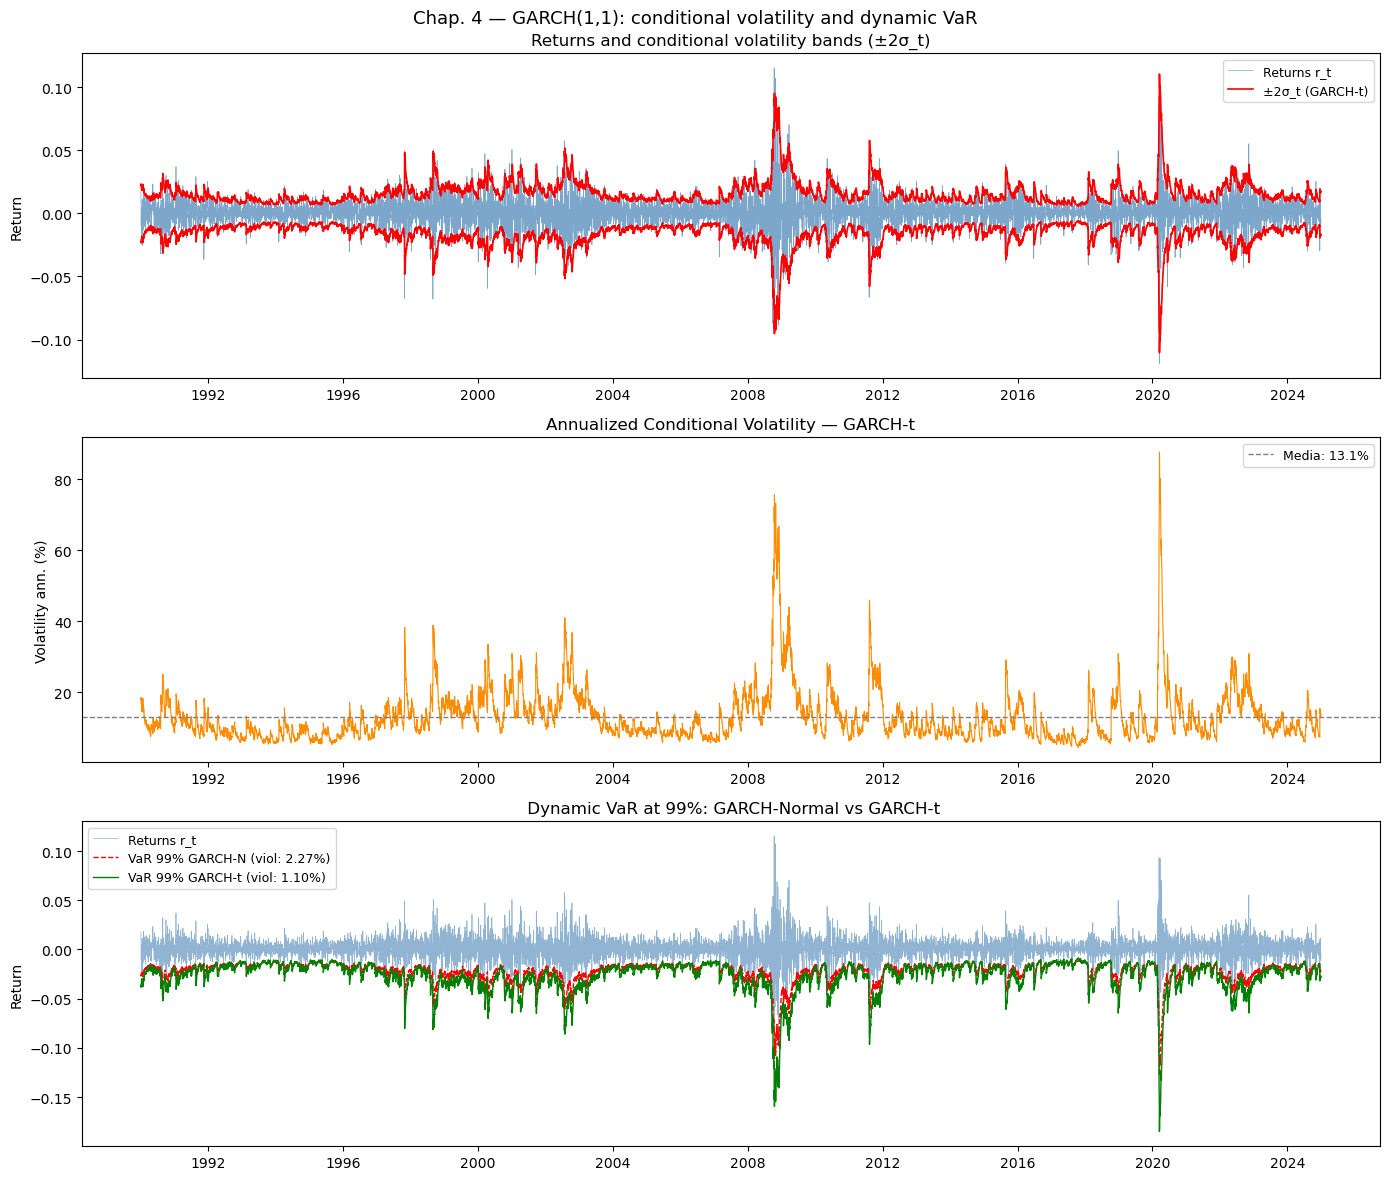

Grafico salvato: cap4_garch.png


In [8]:
# ==============================================================
# CELLA 8 — Grafici
# ==============================================================
 
dates = sp["DlyCalDt"].values
 
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Chap. 4 — GARCH(1,1): conditional volatility and dynamic VaR", fontsize=13)
 
# Pannello 1: rendimenti e volatilità condizionale
ax = axes[0]
ax.plot(dates, r, color="steelblue", lw=0.5, alpha=0.7, label="Returns r_t")
ax.plot(dates, 2*np.sqrt(sigma2_t), color="red", lw=1.2, label="±2σ_t (GARCH-t)")
ax.plot(dates, -2*np.sqrt(sigma2_t), color="red", lw=1.2)
ax.set_ylabel("Return")
ax.set_title("Returns and conditional volatility bands (±2σ_t)")
ax.legend(fontsize=9)
 
# Pannello 2: volatilità condizionale annualizzata
ax = axes[1]
vol_annual = np.sqrt(sigma2_t * 252) * 100
ax.plot(dates, vol_annual, color="darkorange", lw=0.8)
ax.set_ylabel("Volatility ann. (%)")
ax.set_title("Annualized Conditional Volatility — GARCH-t")
ax.axhline(vol_annual.mean(), color="gray", lw=1, linestyle="--", label=f"Media: {vol_annual.mean():.1f}%")
ax.legend(fontsize=9)
 
# Pannello 3: VaR dinamico
ax = axes[2]
ax.plot(dates, r, color="steelblue", lw=0.5, alpha=0.6, label="Returns r_t")
ax.plot(dates, VaR_gn, color="red",    lw=1, linestyle="--", label=f"VaR 99% GARCH-N (viol: {viol_gn*100:.2f}%)")
ax.plot(dates, VaR_gt, color="green",  lw=1, linestyle="-",  label=f"VaR 99% GARCH-t (viol: {viol_gt*100:.2f}%)")
ax.set_ylabel("Return")
ax.set_title(" Dynamic VaR at 99%: GARCH-Normal vs GARCH-t")
ax.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("cap4_garch.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico salvato: cap4_garch.png")

In [9]:
# ==============================================================
# CELLA 9 — Tabella riassuntiva finale
# ==============================================================
 
print("=" * 65)
print("TABELLA RIASSUNTIVA — CAPITOLO 4")
print("=" * 65)
 
risultati = pd.DataFrame({
    "Modello":        ["GARCH-Normal", "GARCH-t"],
    "α (alpha)":      [round(alpha_n, 4), round(alpha_t, 4)],
    "β (beta)":       [round(beta_n,  4), round(beta_t,  4)],
    "α+β":            [round(alpha_n+beta_n, 4), round(alpha_t+beta_t, 4)],
    "ν":              ["-", round(nu_t, 2)],
    "LogL":           [round(ll_norm_g, 1), round(ll_t_g, 1)],
    "AIC":            [round(aic_gn, 1), round(aic_gt, 1)],
    "ΔAIC":           [round(aic_gn-best_aic, 1), round(aic_gt-best_aic, 1)],
    "Kurt. residui":  [round(kurt_zn, 2), round(kurt_zt, 2)],
    "Viol. VaR 99%":  [f"{viol_gn*100:.2f}%", f"{viol_gt*100:.2f}%"],
})
 
print(risultati.to_string(index=False))
risultati.to_csv("cap4_risultati.csv", index=False)
 
print(f"\nCONCLUSIONE CAPITOLO 4:")
print("-" * 65)
print(f"Il GARCH-t batte il GARCH-Normal (ΔAIC = {abs(aic_gn-aic_gt):.1f}).")
print(f"La kurtosis dei residui standardizzati scende da {kurt_zn:.2f}")
print(f"(rendimenti grezzi: 13.28) a {kurt_zt:.2f} sotto GARCH-t,")
print(f"ma resta > 3: i fat tails sono parzialmente spiegati dal")
print(f"volatility clustering, ma non interamente.")
print(f"Questo giustifica il Capitolo 5: il mercato delle opzioni")
print(f"prezza questi fat tails strutturali attraverso il volatility skew.")
print(f"\nFile salvati: cap4_garch.png, cap4_risultati.csv")

TABELLA RIASSUNTIVA — CAPITOLO 4
     Modello  α (alpha)  β (beta)  α+β    ν    LogL      AIC  ΔAIC  Kurt. residui Viol. VaR 99%
GARCH-Normal       0.08      0.88 0.96    - 28871.6 -57735.3 464.3           4.65         2.27%
     GARCH-t       0.08      0.88 0.96  5.0 29104.8 -58199.5   0.0           5.15         1.10%

CONCLUSIONE CAPITOLO 4:
-----------------------------------------------------------------
Il GARCH-t batte il GARCH-Normal (ΔAIC = 464.3).
La kurtosis dei residui standardizzati scende da 4.65
(rendimenti grezzi: 13.28) a 5.15 sotto GARCH-t,
ma resta > 3: i fat tails sono parzialmente spiegati dal
volatility clustering, ma non interamente.
Questo giustifica il Capitolo 5: il mercato delle opzioni
prezza questi fat tails strutturali attraverso il volatility skew.

File salvati: cap4_garch.png, cap4_risultati.csv
